# Ridge Regression

**Reduced Feature Set (PCA)**

Author: Pete King

Here we test whether a smaller input feature set derived using dimensionality reduction via PCA improves the model's ability to predict future volatility. 

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.linear_model import Lasso, Ridge, ElasticNet

import data_prep as dp

DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_etf_data.csv'
PCA_TRAIN_DATA_FILE = DATA_FOLDER + 'train_pca_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_etf_data.csv'
PCA_VAL_DATA_FILE = DATA_FOLDER + 'val_pca_data.csv'
TICKER = 'SPY'  # ETF selected for this analysis

## I. Import data

Here we combine the PCA-derived feature set with base features (return, historical volatility) for an ETF of interest.

In [2]:
# Combine PCA data with base data. From base data, select only historical 
# volatility and future volatility target.
train_df = dp.make_pca_df(TRAIN_DATA_FILE, PCA_TRAIN_DATA_FILE, TICKER)
val_df = dp.make_pca_df(VAL_DATA_FILE, PCA_VAL_DATA_FILE, TICKER)
train_df

,SPY_vol-h,SPY_vol_target,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,,,
2015-10-22,0.007990,0.008038,-0.060385,-0.049302,-0.045180,-0.042780,-0.051164,-0.030192,-0.027020,-0.035612,-0.031673,0.003920,-0.004416,-0.028761
2015-10-23,0.008700,0.007682,-0.019623,-0.042593,-0.040932,-0.026452,-0.008330,-0.036960,-0.000326,-0.024071,-0.030029,-0.043408,-0.038998,-0.035716
2015-10-26,0.008729,0.007669,-0.048401,-0.050450,-0.037413,-0.043599,-0.024643,0.013070,-0.043886,-0.037661,-0.007188,0.011014,0.006914,0.076367
2015-10-27,0.008519,0.007657,0.080811,0.070985,-0.022329,-0.023923,-0.006781,-0.033949,-0.052711,-0.068107,-0.069678,-0.046203,-0.056724,-0.043523
2015-10-28,0.009114,0.007253,-0.030986,0.005244,0.009962,0.023684,0.088783,0.087957,0.062373,0.050440,0.093646,0.074613,0.138485,0.129804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-25,0.007469,0.012897,0.308083,0.293317,0.318319,0.347146,0.318630,0.352572,0.230029,0.244636,0.167978,0.168873,0.253616,0.223574
2022-11-28,0.008508,0.012706,0.216470,0.328980,0.303408,0.250322,0.259765,0.119006,0.294609,0.296493,0.182851,0.184875,0.276096,0.106277
2022-11-29,0.008086,0.013284,0.116745,0.214495,0.206188,0.362023,0.225342,0.231037,0.320214,0.402303,0.318870,0.307361,0.372419,0.285724


In [3]:
val_df

,SPY_vol-h,SPY_vol_target,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,,,
2023-01-03,0.010242,0.011025,0.453110,0.416835,0.381414,0.326702,0.354621,0.360311,0.337204,0.291585,0.291259,0.358576,0.305696,0.317675
2023-01-04,0.010177,0.011143,0.311223,0.310984,0.294959,0.261770,0.240383,0.213406,0.250842,0.217873,0.185065,0.198466,0.206405,0.258067
2023-01-05,0.010796,0.010940,0.235417,0.230884,0.254676,0.296916,0.303690,0.282478,0.260471,0.297770,0.289716,0.382678,0.367219,0.349151
2023-01-06,0.012081,0.010161,0.388915,0.363785,0.384096,0.367638,0.377479,0.353326,0.390000,0.430783,0.401736,0.431695,0.521250,0.756041
2023-01-09,0.011195,0.010439,0.699941,0.724333,0.684553,0.786744,0.791241,0.633941,0.517984,0.574988,0.709907,0.622068,0.578386,0.536060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,0.009243,0.008510,0.509651,0.481606,0.525170,0.567170,0.541915,0.505196,0.598294,0.651030,0.650908,0.698193,0.788185,0.639709
2024-08-27,0.007682,0.008549,0.554635,0.607626,0.603924,0.728833,0.711125,0.669326,0.697178,0.710301,0.669767,0.606121,0.689005,0.623749
2024-08-28,0.007836,0.008460,0.716737,0.673490,0.504542,0.574394,0.530578,0.569836,0.579799,0.571859,0.594947,0.587029,0.616483,0.510084


### Split data and scale features

Again we take advantage of scikit-learn's dedicated splitting function for time series data to preserve chronological order between training and validation data during cross-validation.

In [4]:
# Separate features from labels
# Note: exclude daily return data from the PCA run
data_cols, _ = dp.get_X_y_cols(train_df, returns=False)
label_col = [TICKER + '_vol_target']
# Training set
X_train = train_df.dropna()[data_cols].astype(np.float32)
y_train = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Validation set
X_val = val_df.dropna()[data_cols].astype(np.float32)
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=252,
    gap=21
)
# Scale input features
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=data_cols
)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=data_cols)

## II. Define model, fit to data, and evaluate performance

Here we again tune the model's 'alpha' parameter to control model complexity and avoid overfitting to training data.

In [5]:
# Define model, metrics, and Grid Search for hyperparameter tuning
estimator = Ridge()
metrics = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MSE': 'neg_mean_squared_error',
    'r2': 'r2'
}
params = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1]
}
reg = GridSearchCV(
    estimator,
    params,
    scoring=metrics,
    refit='MAE',
    cv=ts_cv
)

In [6]:
reg.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'RMSE': 'neg_root_mean_squared_error', 'r2': 'r2'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'MAE'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...test_size=252)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

### Visualize performance; Check evaluation metrics

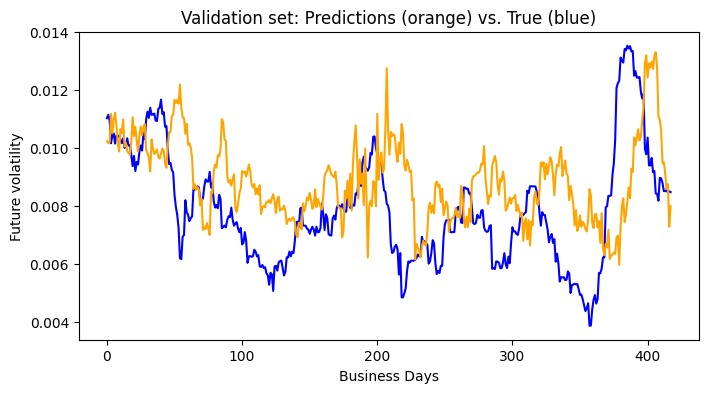

In [7]:
# Use the best estimator to make predictions on the validation set
best = reg.best_estimator_
preds = best.predict(X_val_scaled)
x = range(len(y_val))

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Business Days')
ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')

In [8]:
print(f'MAE: {mean_absolute_error(y_val, preds)}')
print(f'R2: {r2_score(y_val, preds)}')

MAE: 0.00182714790571481
R2: -0.3528252840042114


From the plot we see that the model tends to follow the general future volatility trend fairly well, although its predictions show a pronounced lag behind true historical volatility.  Feature extraction using PCA has improved mean absolute error (MAE) considerably -- down from roughly 0.0045 to 0.0018.

We also see a greatly improved R-squared value up from -6.15 to -0.35, although these scores are still negative.  Normally we expect R-squared in a range between (0, 1), but negative values of R-squared are possible.  Sadly this means that our model is doing worse than simply guessing the mean.  Because it's predictions lag true values, it is typically going in the wrong direction: predicting a spike in volatility after it has already occured and volatility is return to a lower baseline.

## III. Inspect model

Since we scaled all input features in the range (0, 1), we can look at the coefficients assigned to each feature to understand which ones are assigned the most weight (greatest coefficients) in the regression.

In [9]:
feature_importances = list(zip(best.feature_names_in_, best.coef_))
for feature, coef in sorted(feature_importances, key=lambda i: -np.abs(i[1])):
    print(f'{feature}: {coef:2.3f}')

SPY_vol-h: 0.039
PCA_macro-2: -0.012
PCA_hret-1: -0.011
PCA_hvol-3: 0.008
PCA_hvol-1: 0.006
PCA_hret-2: -0.006
PCA_macro-4: 0.005
PCA_hvol-2: -0.005
PCA_macro-3: 0.004
PCA_vol-1: 0.004
PCA_hret-3: 0.004
PCA_vol-2: -0.001
PCA_macro-1: -0.000


Here we see that historical volatility for the asset we are trying to predict is clearly the most important feature, althoug recent returns and macroeconomic factors are also important.  The small regression coefficients for the principal components of volatility indicies (PCA_vol-#) is surprising.  I had speculated that the lag we saw was due again to an over-reliance on the volatility indicies like VIX, but this does not appear to be the case.